In [1]:
import networkx as nx
import numpy as np
import pandas as pd
import matplotlib.pyplot as pl
import itertools as it
import knee.rdp as rdp
import knee.kneedle as kneedle

import time

from controlled_zeros import *
from data_generation import *
from weight_computer import *

import matplotlib
font = {'size'   : 11}

matplotlib.rc('font', **font)

In [2]:
from castle.common import GraphDAG, independence_tests
from castle.metrics import MetricsDAG
from castle.algorithms import PC

2023-12-18 13:06:58,161 - /home/filipe/anaconda3/envs/pythenv39/lib/python3.9/site-packages/castle/backend/__init__.py[line:36] - INFO: You can use `os.environ['CASTLE_BACKEND'] = backend` to set the backend(`pytorch` or `mindspore`).
2023-12-18 13:06:58,530 - /home/filipe/anaconda3/envs/pythenv39/lib/python3.9/site-packages/castle/algorithms/__init__.py[line:36] - INFO: You are using ``pytorch`` as the backend.


In [3]:
def condition(node_list, arr ,m):
    H = nx.DiGraph()
    H.add_nodes_from(node_list)
    H.add_edges_from(np.unique(arr[m:],axis=1))
    return nx.is_connected(H.to_undirected())

def binary_search(node_list, arr):
    '''arr - sorted array'''
    L=0
    R=len(arr)-1
    while L<=R:
        if L==R:
            return L
        
        m = int((L+R)/2)+1
        if not condition(node_list, arr, m): #is it not connected?
            R = m-1
        else:
            L = m
    return "fail"

def triangulation(df, edge_list, thres, states):
    DAG_w2 = nx.DiGraph()
    DAG_w2.add_nodes_from(df.columns)
    DAG_w2.add_edges_from(edge_list)
    
    for b in np.array(DAG_w2.nodes)[np.array(DAG_w2.in_degree)[:,1].astype("int")>1]:
        parents = np.array(list(DAG_w2.in_edges(b)))[:,0]
        
        for a in parents: #a-> b <-u (test a->b; b=node)
            if (a,b) not in DAG_w2.edges: #was it already removed?
                continue
            #Note: it.permutations(parents,2) can't be used in conjuction with the last break since that will cause the cycle to skip triangles for different a's.
            for c in parents[parents!=a]:
                #print(b,a,parents[parents!=a])
                survives=False

                for st_varB,st_varA,st_varC in it.product(*[states[b],states[a],states[c]]):
                    PC = (df[c]==st_varC).sum()
                    PAC= ((df[a]==st_varA)&(df[c]==st_varC)).sum()
                    PBC= ((df[b]==st_varB)&(df[c]==st_varC)).sum()
                    PABC= ((df[b]==st_varB)&(df[a]==st_varA)&(df[c]==st_varC)).sum()
                    if PAC!=0 and PAC!=PC: #conditioned to c
                        if np.abs(PABC*PC-PAC*PBC)/(PAC*(PC-PAC)) > thres:
                            survives=True
                            break

                if not survives:
                    DAG_w2.remove_edge(a,b)
                    #if (DAG_w2.out_degree(a) == 0):
                    #    if order[a]<order[c]:
                    #        DAG_w2.add_edge(a,c)
                    #    if order[c]<order[a]:
                    #        DAG_w2.add_edge(c,a)

                    break
    return DAG_w2

def triangulation2(data, node_list, edge_list, thres):
    key = {df.columns[i]:i for i in range(len(df.columns))}
    DAG_w2 = nx.DiGraph()
    DAG_w2.add_nodes_from(node_list)
    DAG_w2.add_edges_from(edge_list)
    
    for b in np.array(DAG_w2.nodes)[np.array(DAG_w2.in_degree)[:,1].astype("int")>1]:
        parents = np.array(list(DAG_w2.in_edges(b)))[:,0]
        
        for a in parents: #a-> b <-u (test a->b; b=node)
            if (a,b) not in DAG_w2.edges: #was it already removed?
                continue
            #Note: it.permutations(parents,2) can't be used in conjuction with the last break since that will cause the cycle to skip triangles for different a's.
            for c in parents[parents!=a]:
                #print(b,a,parents[parents!=a])
                if independence_tests.CITest.fisherz_test(data,key[a],key[b],[key[c]])[2] > thres: #does not survive
                    DAG_w2.remove_edge(a,b)
                    break
                    
    return DAG_w2

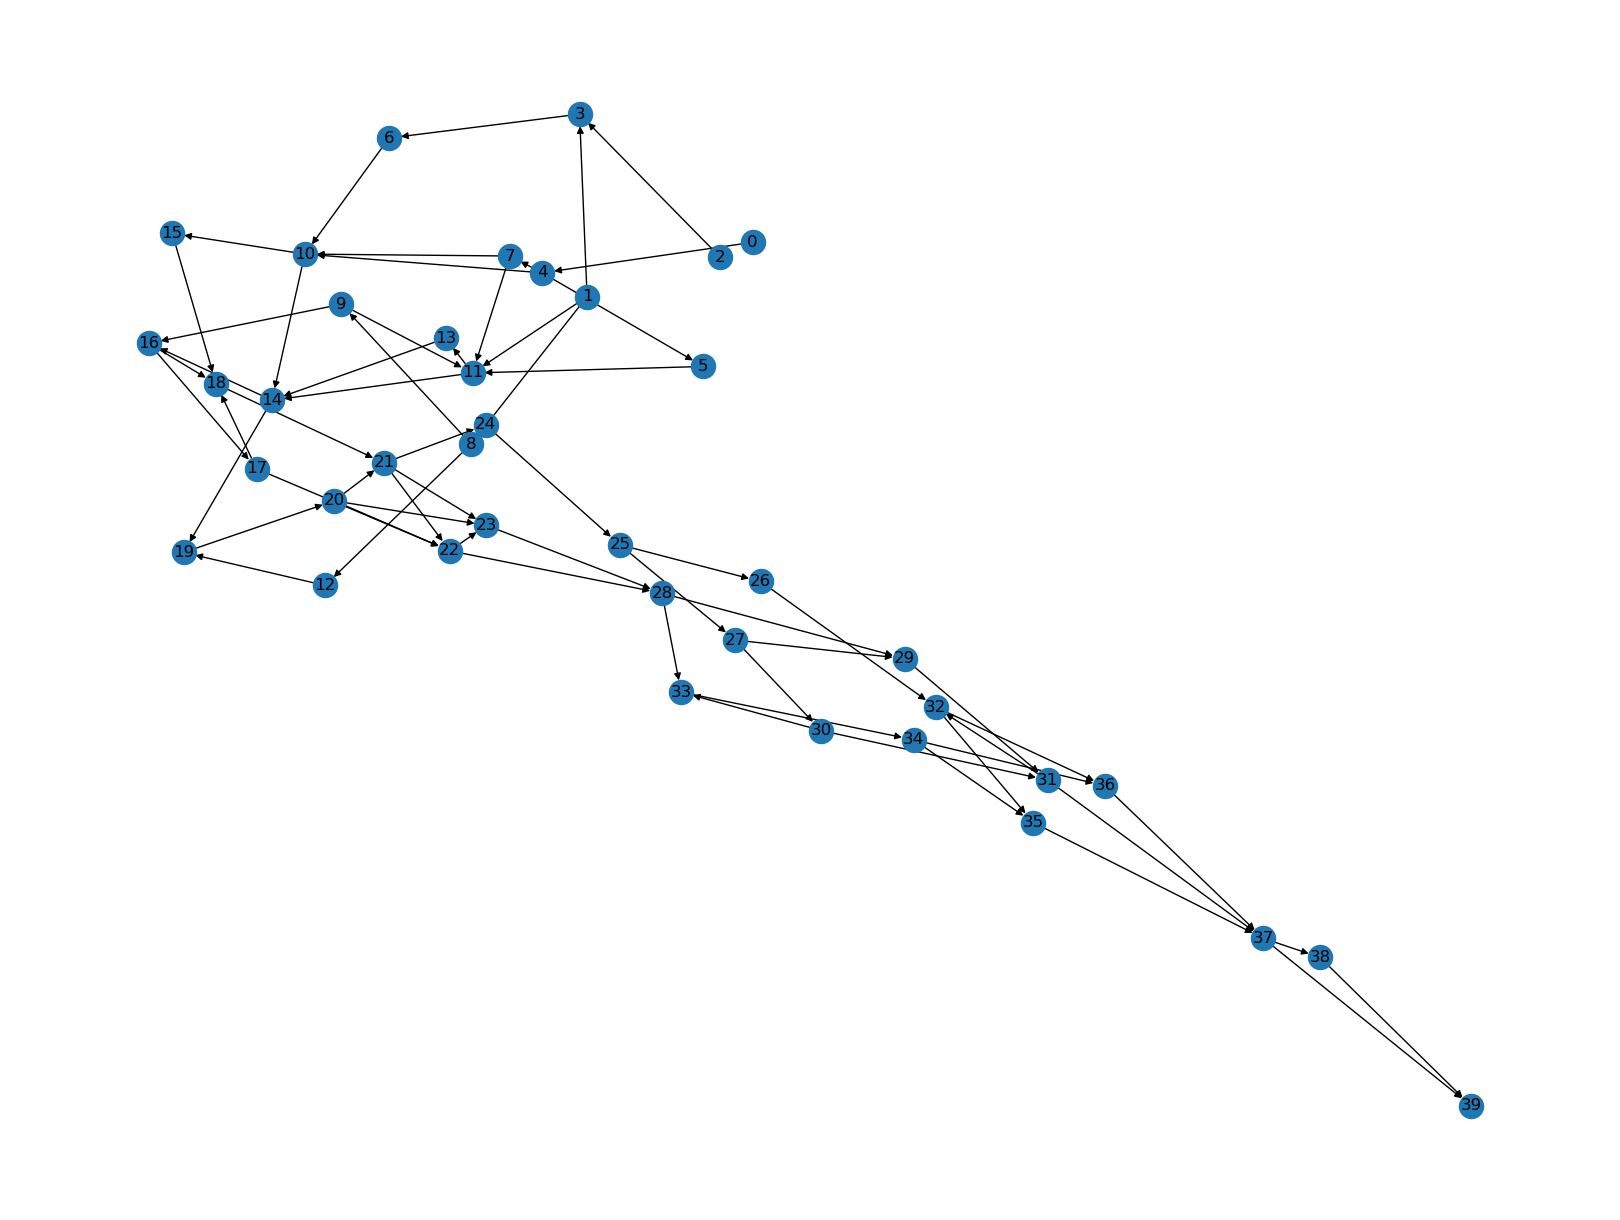

In [4]:
pl.figure(figsize=(16,12))
n_nodes, density, orphans = 40, 2, 0.01
DAGt = controlled_zeros(n_nodes, density, orphans)
DAGt = nx.relabel_nodes(DAGt,{node:str(node) for node in DAGt.nodes})
nx.draw(DAGt,with_labels=True)
pl.show()

states = stater(DAGt, min_states=2, max_states=4)
states_prob = probabiliter_controlled(DAGt, states)
df = generator(DAGt, states, states_prob, 10000)
order = {node:int(node) for node in DAGt.nodes}

In [5]:
np.mean((np.array(DAGt.in_degree)[:,1]).astype("int"))

1.6

In [6]:
a = np.zeros(np.shape(df))
i=0
for col in df:
    #print(df[col])
    j=0
    for st in states[col]:
        a[:,i][np.where(df[col]==st)]=j
        j+=1
    i+=1

In [7]:
fish_vals = [independence_tests.CITest.fisherz_test(a,x,y,[])[2] for x,y in it.permutations(range(len(a[0])),2)]
fish_vars = [(x,y) for x,y in it.permutations(list(df.columns),2)]

unique_edges, unique_vals = np.array(fish_vars)[np.argsort(fish_vals)], np.sort(fish_vals)
unique_edges = np.flip(unique_edges)
unique_vals = np.flip(unique_vals)

In [8]:
for i in np.unique(unique_vals,return_index=True)[1]:
    H = nx.Graph()
    H.add_nodes_from(df.columns)
    H.add_edges_from(unique_edges[i:])
    if nx.is_connected(H):
        m = i
        break
print(m)

1386


0.00028544362353444264


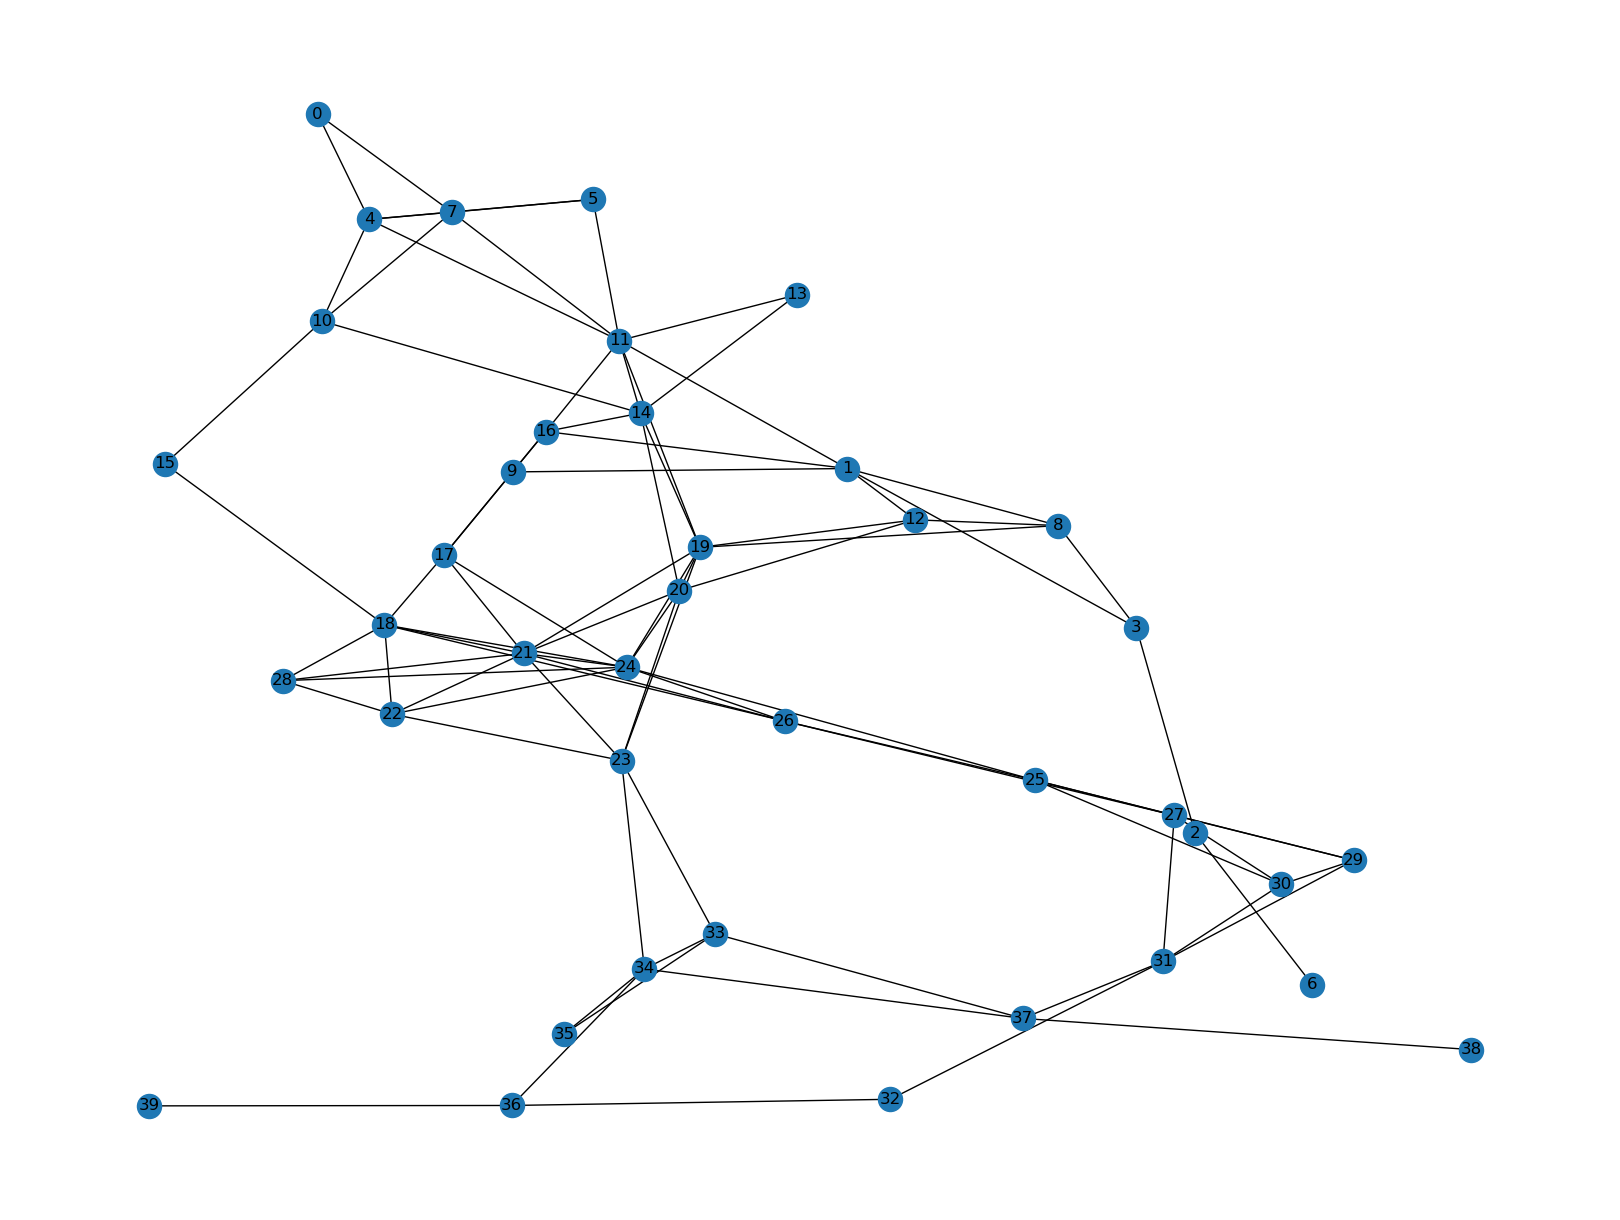

17 67


In [9]:
thres = unique_vals[m]
print(thres)

DAG_w = nx.Graph()
DAG_w.add_edges_from(unique_edges[m:],color="k")

pl.figure(figsize=(16,12))
nx.draw(DAG_w,with_labels=True)
pl.show()

excess = DAG_w.edges-DAGt.edges
missing= DAGt.edges-DAG_w.edges

print( len(missing), len(excess) )

In [10]:
gcc_nodes=np.zeros(len(unique_edges))
for i in range(len(unique_edges)):
    DAGi = nx.DiGraph()
    DAGi.add_edges_from(unique_edges[i:])
    gcc_nodes[i] = len(sorted(nx.connected_components(DAGi.to_undirected()), key=len, reverse=True)[0])
del DAGi
m = kneedle.auto_knee(np.column_stack((np.arange(len(gcc_nodes)),gcc_nodes)))
print(m)

1431


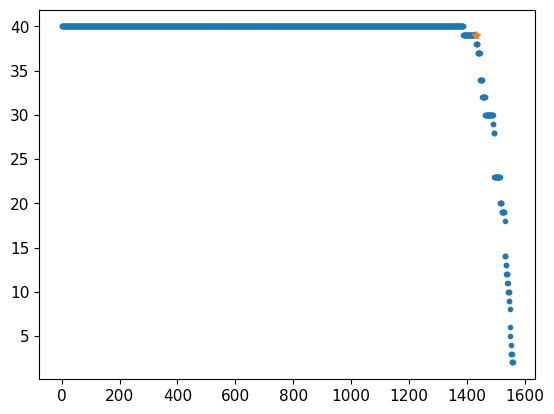

In [11]:
pl.plot(np.arange(len(gcc_nodes)),gcc_nodes,'.')
pl.plot(m,gcc_nodes[m],'*')
pl.show()

9.423038194178446e-08


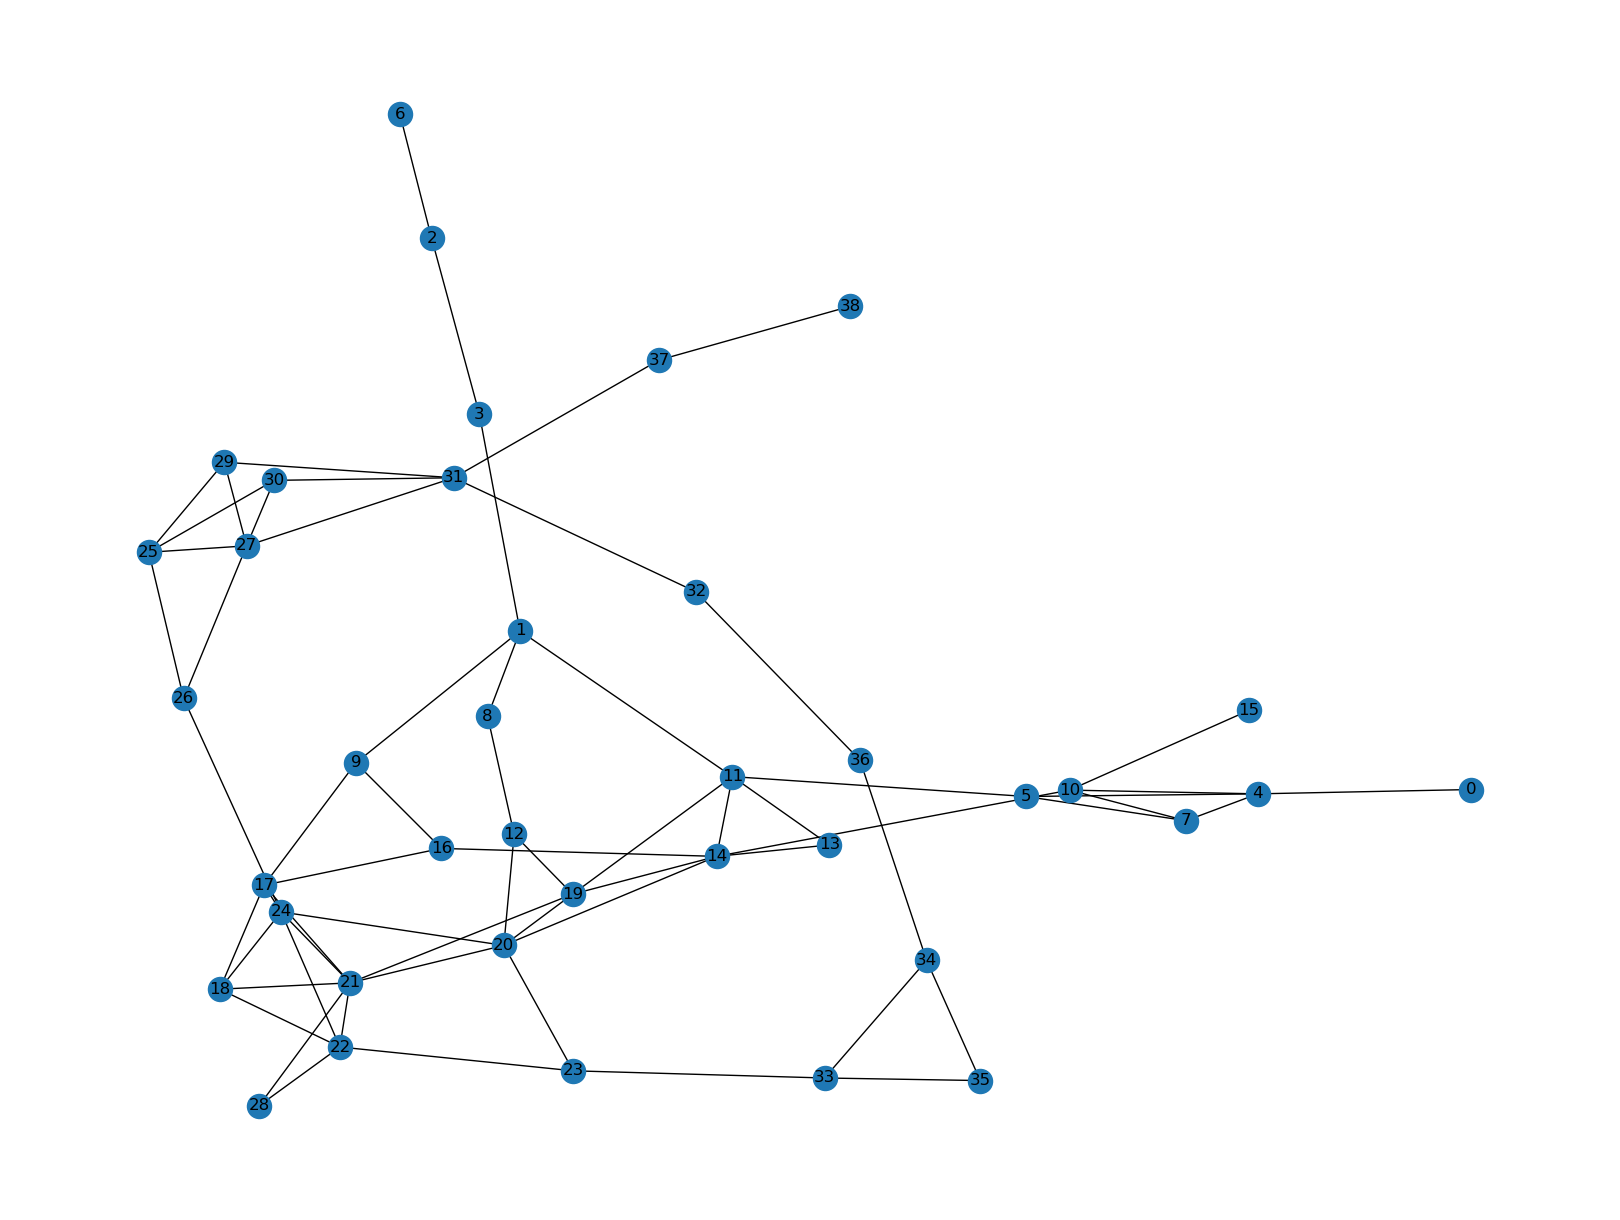

21 38


In [12]:
thres = unique_vals[m]
print(thres)

DAG_w = nx.Graph()
DAG_w.add_edges_from(unique_edges[m:],color="k")

pl.figure(figsize=(16,12))
nx.draw(DAG_w,with_labels=True)
pl.show()

excess = DAG_w.edges-DAGt.edges
missing= DAGt.edges-DAG_w.edges

print( len(missing), len(excess) )

In [13]:
alphas = np.arange(0.0,0.1,0.01)
miss_exc = np.zeros([len(alphas),2])
times = np.zeros(len(alphas))

true_matrix=nx.adjacency_matrix(DAGt,nodelist=df.columns).toarray()
for i in range(len(alphas)):
    ti = time.process_time_ns()
    pc = PC(alpha=alphas[i])
    pc.learn(a)
    times[i] = time.process_time_ns() - ti
    
    missing = int(np.sum((true_matrix-pc.causal_matrix)>0))
    excess = int(np.sum((true_matrix-pc.causal_matrix)<0))
    miss_exc[i] = missing, excess
    print(i)
    
#GraphDAG(pc.causal_matrix, true_matrix, 'result')

0
1
2
3
4
5
6
7
8
9


[38. 53.]


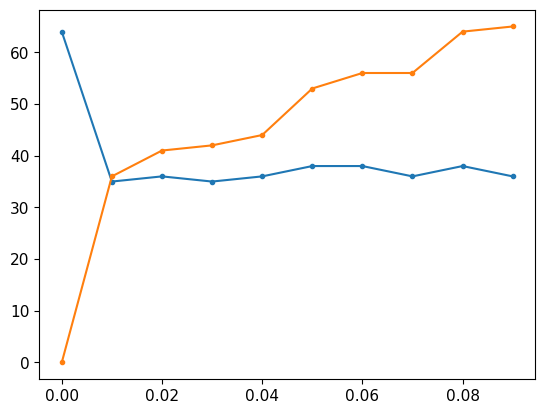

In [14]:
pl.plot(alphas,miss_exc[:,0],'.-')
pl.plot(alphas,miss_exc[:,1],'.-')
print(miss_exc[5])
pl.show()

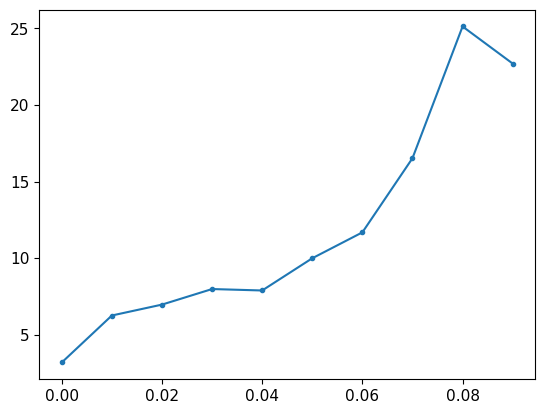

In [15]:
pl.plot(alphas,times*1e-9,'.-')
pl.show()

In [16]:
ti = time.process_time_ns()
#FIRST STEP
fish_vals = [independence_tests.CITest.fisherz_test(a,x,y,[])[2] for x,y in it.permutations(range(len(a[0])),2)]
fish_vars = [(x,y) for x,y in it.permutations(list(df.columns),2)]

unique_edges, unique_vals = np.array(fish_vars)[np.argsort(fish_vals)], np.sort(fish_vals)
unique_edges = np.flip(unique_edges)
unique_vals = np.flip(unique_vals)

##Threshold without knee
for i in np.unique(unique_vals,return_index=True)[1]:
    H = nx.Graph()
    H.add_nodes_from(df.columns)
    H.add_edges_from(unique_edges[i:])
    if nx.is_connected(H):
        m = i
        break
thres = unique_vals[m]
print(thres)

#SECOND STEP
DAG_w2 = triangulation2(a, df.columns, unique_edges[m:], thres)

print((time.process_time_ns() - ti)*1e-9)

excess = DAG_w2.edges-DAGt.edges
missing= DAGt.edges-DAG_w2.edges

print( len(missing), len(excess) )

0.00028544362353444264
3.1296445470000003
20 68


In [17]:
ti = time.process_time_ns()
#FIRST STEP
fish_vals = [independence_tests.CITest.fisherz_test(a,x,y,[])[2] for x,y in it.permutations(range(len(a[0])),2)]
fish_vars = [(x,y) for x,y in it.permutations(list(df.columns),2)]

unique_edges, unique_vals = np.array(fish_vars)[np.argsort(fish_vals)], np.sort(fish_vals)
unique_edges = np.flip(unique_edges)
unique_vals = np.flip(unique_vals)

##Threshold with knee
gcc_nodes=np.zeros(len(unique_edges))
for i in range(len(unique_edges)):
    DAGi = nx.Graph()
    DAGi.add_edges_from(unique_edges[i:])
    gcc_nodes[i] = len(sorted(nx.connected_components(DAGi), key=len, reverse=True)[0])
del DAGi
m = kneedle.auto_knee(np.column_stack((np.arange(len(gcc_nodes)),gcc_nodes)))
thres = unique_vals[m]
print(thres)

#SECOND STEP
DAG_w2 = triangulation2(a, df.columns, unique_edges[m:], thres)

print((time.process_time_ns() - ti)*1e-9)

excess = DAG_w2.edges-DAGt.edges
missing= DAGt.edges-DAG_w2.edges

print( len(missing), len(excess) )

9.423038194178446e-08
7.077533355000001
24 58


In [18]:
ti = time.process_time_ns()
#FIRST STEP
weight_num_writer(df.loc[:], states, order)
wn_var = np.array(weight_var_importer('weights_num.txt'))
wn_val = np.array(weight_val_importer('weights_num.txt'))
    
unique_edges = np.unique(wn_var[:,:2],axis=0)
unique_vals = np.zeros(len(unique_edges))
for i in range(len(unique_edges)):
    pair = unique_edges[i]
    unique_vals[i] = (np.max( np.abs( wn_val[np.all(wn_var[:,:2]==pair,axis=1)]) ) )
unique_vals=np.abs(unique_vals)
unique_edges, unique_vals = unique_edges[np.argsort(unique_vals)], np.sort(unique_vals)

##Threshold without knee
m=binary_search(list(states), unique_edges)
thres = unique_vals[m]
print(thres)

#SECOND STEP
DAG_w2 = triangulation(df, unique_edges[m:], thres, states)

print((time.process_time_ns() - ti)*1e-9)

excess = DAG_w2.edges-DAGt.edges
missing= DAGt.edges-DAG_w2.edges

print( len(missing), len(excess) )

0.040528150387207994
7.245578578000001
4 51


In [19]:
ti = time.process_time_ns()
#FIRST STEP
weight_num_writer(df.loc[:], states, order)
wn_var = np.array(weight_var_importer('weights_num.txt'))
wn_val = np.array(weight_val_importer('weights_num.txt'))
    
unique_edges = np.unique(wn_var[:,:2],axis=0)
unique_vals = np.zeros(len(unique_edges))
for i in range(len(unique_edges)):
    pair = unique_edges[i]
    unique_vals[i] = (np.max( np.abs( wn_val[np.all(wn_var[:,:2]==pair,axis=1)]) ) )
unique_vals=np.abs(unique_vals)
unique_edges, unique_vals = unique_edges[np.argsort(unique_vals)], np.sort(unique_vals)

##Threshold with knee
gcc_nodes=np.zeros(len(unique_edges))
for i in range(len(unique_edges)):
    DAGi = nx.Graph()
    DAGi.add_edges_from(unique_edges[i:])
    gcc_nodes[i] = len(sorted(nx.connected_components(DAGi), key=len, reverse=True)[0])
del DAGi
m = kneedle.auto_knee(np.column_stack((np.arange(len(gcc_nodes)),gcc_nodes)))
thres = unique_vals[m]
print(thres)

#SECOND STEP
DAG_w2 = triangulation(df, unique_edges[m:], thres, states)

print((time.process_time_ns() - ti)*1e-9)


excess = DAG_w2.edges-DAGt.edges
missing= DAGt.edges-DAG_w2.edges

print( len(missing), len(excess) )

0.10481243222013986
5.523535470000001
15 7
